# ITAI 1371 Module 11: Hyperparameter Tuning & AutoML

Welcome to Module 11 of ITAI 1371! In this notebook, we'll dive deep into **hyperparameter tuning** and explore the exciting world of **AutoML** using classic machine learning methods. Our goal is to understand how tuning hyperparameters affects model performance and how automated tools can help us find the best models.

We'll work with the **Wine Quality dataset**, transforming it into a binary classification problem (good vs bad wine). Throughout the lab, you'll find detailed explanations, visualizations, and exercises to build your skills.

---

## Part 1 - Pre-coded Sections with Explanations

### 1. Header & Introduction

In this section, we'll outline the goals and structure of today's lab.

### Goals for this module:
- Understand what hyperparameters are and why they matter.
- Learn the difference between parameters and hyperparameters.
- Explore the bias-variance tradeoff and how hyperparameters influence it.
- Use cross-validation to evaluate models properly.
- Perform manual hyperparameter tuning and automated methods like Grid Search and Random Search.
- Try out AutoML using AutoGluon and compare results.

### Dataset:
- Wine Quality dataset (binary classification: good vs bad wine).

Let's get started!

### Deep Dive: Hyperparameters in Different Algorithms

Different machine learning algorithms have different hyperparameters. Understanding what each hyperparameter controls is crucial for effective tuning. Let's explore hyperparameters across several common algorithms:

**Random Forest:**
- `n_estimators`: Number of trees in the forest. More trees generally improve performance but increase computation time.
- `max_depth`: Maximum depth of each tree. Controls model complexity and overfitting.
- `min_samples_split`: Minimum samples required to split a node. Higher values prevent overfitting.
- `max_features`: Number of features to consider for each split. Adds randomness to reduce overfitting.

**Support Vector Machine (SVM):**
- `C`: Regularization parameter. Lower values mean stronger regularization.
- `kernel`: Type of kernel function (linear, rbf, poly). Determines decision boundary shape.
- `gamma`: Kernel coefficient for RBF. Controls influence of single training examples.

**Logistic Regression:**
- `C`: Inverse regularization strength. Smaller values mean stronger regularization.
- `penalty`: Type of regularization (l1, l2, elasticnet).
- `solver`: Algorithm for optimization (lbfgs, saga, etc.).

In [19]:
# Example: Viewing default hyperparameters
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Create models with default hyperparameters
rf = RandomForestClassifier()
svm = SVC()
lr = LogisticRegression()

print("Random Forest Default Hyperparameters:")
print(f"  n_estimators: {rf.n_estimators}")
print(f"  max_depth: {rf.max_depth}")
print(f"  min_samples_split: {rf.min_samples_split}")
print(f"  max_features: {rf.max_features}")

print("\nSVM Default Hyperparameters:")
print(f"  C: {svm.C}")
print(f"  kernel: {svm.kernel}")
print(f"  gamma: {svm.gamma}")

print("\nLogistic Regression Default Hyperparameters:")
print(f"  C: {lr.C}")
print(f"  penalty: {lr.penalty}")
print(f"  solver: {lr.solver}")

Random Forest Default Hyperparameters:
  n_estimators: 100
  max_depth: None
  min_samples_split: 2
  max_features: sqrt

SVM Default Hyperparameters:
  C: 1.0
  kernel: rbf
  gamma: scale

Logistic Regression Default Hyperparameters:
  C: 1.0
  penalty: l2
  solver: lbfgs


### 🤔 Knowledge Check: Hyperparameter Understanding

**Question 1 (Conceptual):** If you wanted to reduce overfitting in a Random Forest model, which hyperparameters would you adjust and in what direction?

*Your answer:* To reduce overfitting in a Random Forest model, I would decrease the maximum depth (`max_depth`) so the trees do not become too complex. I would also increase `min_samples_split` so that more samples are required before a node can split. In some cases, I would also reduce `max_features` to increase randomness between the trees, which can help improve generalization.

---

**Question 2 (Reflective):** 💭 Why do you think scikit-learn chose these specific default values? What assumptions might they be making about typical datasets?

*Your answer:* I think scikit-learn chose these default values because they provide a good balance between accuracy and performance for many different datasets. The defaults are designed to work reasonably well without requiring users to tune every hyperparameter. They assume that most datasets are of average size and complexity, making the default settings a good starting point before further optimization.

### Conceptual Question:
- What do you think hyperparameters are and why might tuning them be important for machine learning models?

Answer: Hyperparameters are settings that are chosen before a model is trained and control how the model learns. Tuning them is important because the right combination can improve accuracy, reduce overfitting, and help the model perform better on new data. Even when using the same algorithm, different hyperparameter values can lead to very different results.

### Deep Dive: Hyperparameters in Different Algorithms

Different machine learning algorithms have different hyperparameters. Understanding what each hyperparameter controls is crucial for effective tuning. Let's explore hyperparameters across several common algorithms:

**Random Forest:**
- `n_estimators`: Number of trees in the forest. More trees generally improve performance but increase computation time.
- `max_depth`: Maximum depth of each tree. Controls model complexity and overfitting.
- `min_samples_split`: Minimum samples required to split a node. Higher values prevent overfitting.
- `max_features`: Number of features to consider for each split. Adds randomness to reduce overfitting.

**Support Vector Machine (SVM):**
- `C`: Regularization parameter. Lower values mean stronger regularization.
- `kernel`: Type of kernel function (linear, rbf, poly). Determines decision boundary shape.
- `gamma`: Kernel coefficient for RBF. Controls influence of single training examples.

**Logistic Regression:**
- `C`: Inverse regularization strength. Smaller values mean stronger regularization.
- `penalty`: Type of regularization (l1, l2, elasticnet).
- `solver`: Algorithm for optimization (lbfgs, saga, etc.).

In [20]:
# Example: Viewing default hyperparameters
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Create models with default hyperparameters
rf = RandomForestClassifier()
svm = SVC()
lr = LogisticRegression()

print("Random Forest Default Hyperparameters:")
print(f"  n_estimators: {rf.n_estimators}")
print(f"  max_depth: {rf.max_depth}")
print(f"  min_samples_split: {rf.min_samples_split}")
print(f"  max_features: {rf.max_features}")

print("\nSVM Default Hyperparameters:")
print(f"  C: {svm.C}")
print(f"  kernel: {svm.kernel}")
print(f"  gamma: {svm.gamma}")

print("\nLogistic Regression Default Hyperparameters:")
print(f"  C: {lr.C}")
print(f"  penalty: {lr.penalty}")
print(f"  solver: {lr.solver}")

Random Forest Default Hyperparameters:
  n_estimators: 100
  max_depth: None
  min_samples_split: 2
  max_features: sqrt

SVM Default Hyperparameters:
  C: 1.0
  kernel: rbf
  gamma: scale

Logistic Regression Default Hyperparameters:
  C: 1.0
  penalty: l2
  solver: lbfgs


### 🤔 Knowledge Check: Hyperparameter Understanding

**Question 1 (Conceptual):** If you wanted to reduce overfitting in a Random Forest model, which hyperparameters would you adjust and in what direction?

*Your answer:* To reduce overfitting, I would decrease the maximum depth (max_depth) so the trees do not become too complex. I would also increase min_samples_split so more samples are required before creating a split, which helps prevent the model from fitting noise in the training data. I could also reduce max_features to add more randomness between the trees and improve generalization.

---

**Question 2 (Reflective):** 💭 Why do you think scikit-learn chose these specific default values? What assumptions might they be making about typical datasets?

*Your answer:* I think scikit-learn chose these default values because they provide a good balance between accuracy, speed, and simplicity for many common datasets. The defaults are intended to give reasonable performance without requiring users to tune every setting. They assume that most datasets have average complexity and that these values are a good starting point before making adjustments for a specific problem.

---

### 2. Setup & Data Loading

Let's load the Wine Quality dataset and prepare it for binary classification.

In [21]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [22]:
# Load the Wine Quality dataset
# Dataset link: https://archive.ics.uci.edu/ml/datasets/Wine+Quality
# We'll use the red wine dataset

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
wine_df = pd.read_csv(url, sep=';')
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Dataset Description:
- 1599 samples
- 11 physicochemical features (e.g., acidity, sugar, pH)
- Target: quality score (0-10 scale)

Our goal: convert quality into a **binary classification** problem:
- Quality >= 7 -> Good wine (label 1)
- Quality < 7 -> Bad wine (label 0)

In [23]:
# Create binary target
wine_df['good_quality'] = (wine_df['quality'] >= 7).astype(int)

# Drop original quality column
wine_df = wine_df.drop('quality', axis=1)

# Check distribution
wine_df['good_quality'].value_counts(normalize=True)

,proportion
good_quality,
0,0.86429
1,0.13571


The dataset is imbalanced, with fewer good quality wines.

### Split dataset into train and test sets

In [24]:
X = wine_df.drop('good_quality', axis=1)
y = wine_df['good_quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 1279
Testing samples: 320


### Feature Scaling

Many ML algorithms perform better with scaled features.

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---

### 3. Understanding Hyperparameters (with examples)

Let's clarify what hyperparameters are by looking at two classic models: Logistic Regression and Random Forest.

### Deep Dive: Hyperparameters in Different Algorithms

Different machine learning algorithms have different hyperparameters. Understanding what each hyperparameter controls is crucial for effective tuning. Let's explore hyperparameters across several common algorithms:

**Random Forest:**
- `n_estimators`: Number of trees in the forest. More trees generally improve performance but increase computation time.
- `max_depth`: Maximum depth of each tree. Controls model complexity and overfitting.
- `min_samples_split`: Minimum samples required to split a node. Higher values prevent overfitting.
- `max_features`: Number of features to consider for each split. Adds randomness to reduce overfitting.

**Support Vector Machine (SVM):**
- `C`: Regularization parameter. Lower values mean stronger regularization.
- `kernel`: Type of kernel function (linear, rbf, poly). Determines decision boundary shape.
- `gamma`: Kernel coefficient for RBF. Controls influence of single training examples.

**Logistic Regression:**
- `C`: Inverse regularization strength. Smaller values mean stronger regularization.
- `penalty`: Type of regularization (l1, l2, elasticnet).
- `solver`: Algorithm for optimization (lbfgs, saga, etc.).

In [26]:
# Example: Viewing default hyperparameters
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Create models with default hyperparameters
rf = RandomForestClassifier()
svm = SVC()
lr = LogisticRegression()

print("Random Forest Default Hyperparameters:")
print(f"  n_estimators: {rf.n_estimators}")
print(f"  max_depth: {rf.max_depth}")
print(f"  min_samples_split: {rf.min_samples_split}")
print(f"  max_features: {rf.max_features}")

print("\nSVM Default Hyperparameters:")
print(f"  C: {svm.C}")
print(f"  kernel: {svm.kernel}")
print(f"  gamma: {svm.gamma}")

print("\nLogistic Regression Default Hyperparameters:")
print(f"  C: {lr.C}")
print(f"  penalty: {lr.penalty}")
print(f"  solver: {lr.solver}")

Random Forest Default Hyperparameters:
  n_estimators: 100
  max_depth: None
  min_samples_split: 2
  max_features: sqrt

SVM Default Hyperparameters:
  C: 1.0
  kernel: rbf
  gamma: scale

Logistic Regression Default Hyperparameters:
  C: 1.0
  penalty: l2
  solver: lbfgs


### 🤔 Knowledge Check: Hyperparameter Understanding

**Question 1 (Conceptual):** If you wanted to reduce overfitting in a Random Forest model, which hyperparameters would you adjust and in what direction?

*Your answer:* To reduce overfitting, I would decrease the maximum depth (`max_depth`) so the trees do not become too complex. I would also increase `min_samples_split` so more samples are required before a split can occur. In addition, I could reduce `max_features` to increase randomness between the trees, which helps the model generalize better to new data.

---

**Question 2 (Reflective):** 💭 Why do you think scikit-learn chose these specific default values? What assumptions might they be making about typical datasets?

*Your answer:* I think scikit-learn chose these default values because they provide a good balance between accuracy, efficiency, and simplicity for many common datasets. The defaults are meant to work reasonably well without requiring users to tune every setting. They assume that most datasets are of average size and complexity, making these values a good starting point before further optimization.

**Logistic Regression hyperparameters:**
- `C`: inverse of regularization strength
- `max_iter`: max number of iterations

**Random Forest hyperparameters:**
- `n_estimators`: number of trees
- `max_depth`: max depth of trees
- `max_features`: number of features considered for best split

Let's see their effect on model performance.

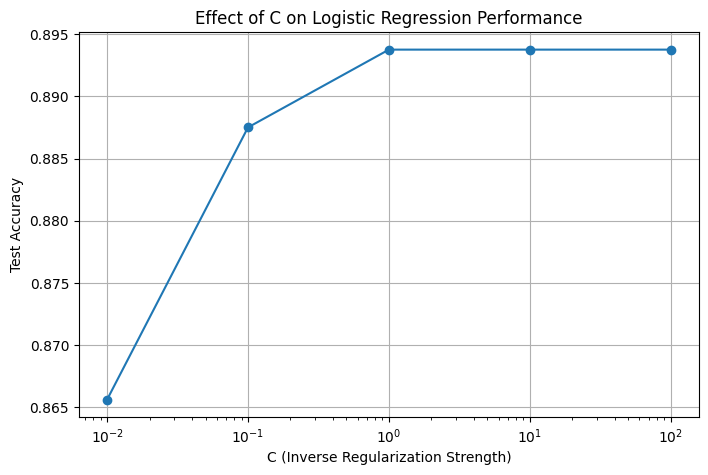

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Logistic Regression with different C values
C_values = [0.01, 0.1, 1, 10, 100]
logreg_scores = []
for c in C_values:
    model = LogisticRegression(C=c, max_iter=200, random_state=42)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    logreg_scores.append(acc)

# Plot results
plt.figure(figsize=(8,5))
plt.plot(C_values, logreg_scores, marker='o')
plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Test Accuracy')
plt.title('Effect of C on Logistic Regression Performance')
plt.grid(True)
plt.show()

### Interpretation:
- Smaller `C` means stronger regularization (simpler model).
- Larger `C` means less regularization (more complex model).
- Accuracy changes with these hyperparameters, demonstrating their importance.

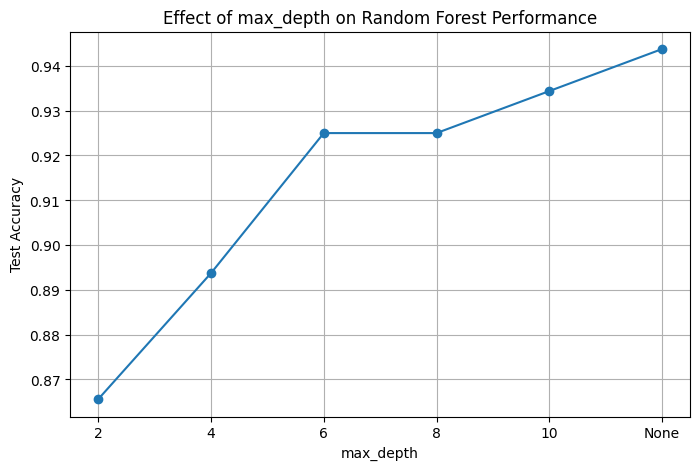

In [28]:
# Random Forest with different max_depth values
depth_values = [2, 4, 6, 8, 10, None]
rf_scores = []
for depth in depth_values:
    model = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    model.fit(X_train, y_train)  # no scaling needed for RF
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    rf_scores.append(acc)

# Plot results
plt.figure(figsize=(8,5))
labels = ['2', '4', '6', '8', '10', 'None']
plt.plot(labels, rf_scores, marker='o')
plt.xlabel('max_depth')
plt.ylabel('Test Accuracy')
plt.title('Effect of max_depth on Random Forest Performance')
plt.grid(True)
plt.show()

### Conceptual Question:
- How might changing the `max_depth` affect underfitting or overfitting? Why?

Answer: Changing `max_depth` controls how complex the decision trees can become. A smaller `max_depth` creates simpler trees, which can lead to underfitting because the model may not capture all the patterns in the data. A larger `max_depth` allows the trees to learn more complex patterns, improving accuracy up to a point. However, if the trees become too deep, they may memorize the training data and overfit, resulting in poorer performance on new, unseen data.

---

### 4. Parameters vs Hyperparameters (detailed explanation)

**Parameters:**
- Learned from the data during training.
- Example: Coefficients in logistic regression, split thresholds in decision trees.

**Hyperparameters:**
- Set before training.
- Control the training process and model complexity.
- Examples: learning rate, number of trees, max depth.

Understanding the difference helps us tune models effectively.

#### Reflective Question:
1. Why can't we learn hyperparameters directly from the training data like parameters?

Answer: Hyperparameters cannot be learned directly from the training data because they control how the learning process works before training begins. They determine the model's structure and complexity, while parameters are the values the model learns during training. Hyperparameters must be chosen or tuned to help the model learn effectively.

2. How might hyperparameters impact the final model's ability to generalize?

Answer: Hyperparameters have a direct impact on how well a model generalizes to new data. If they are set too low or too high, the model may underfit or overfit the training data. Choosing the right hyperparameters helps the model learn the important patterns without memorizing the training data, leading to better performance on unseen data.

---

### 5. Bias-Variance Tradeoff (with visualizations)

The bias-variance tradeoff is a fundamental concept:
- **Bias:** Error from erroneous assumptions in the model.
- **Variance:** Error from sensitivity to small fluctuations in the training set.

Hyperparameters often control this tradeoff.

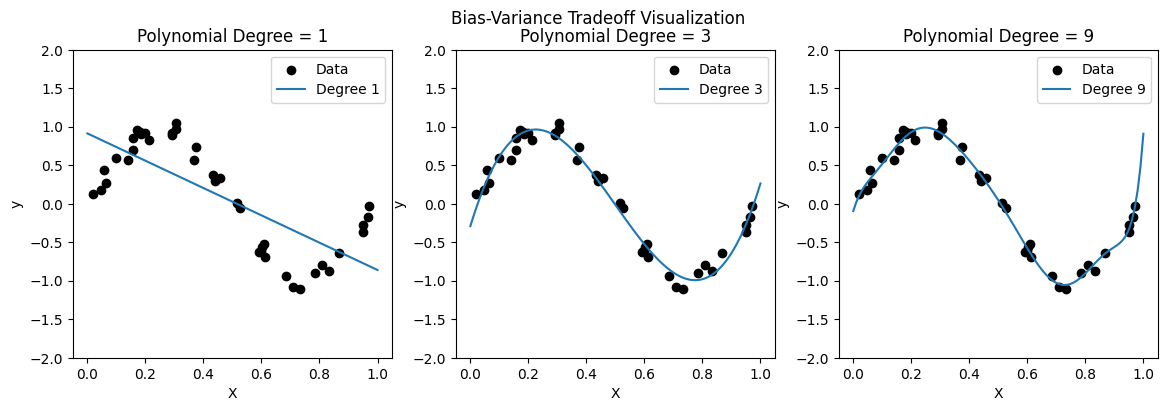

In [29]:
# Visualizing bias-variance tradeoff with polynomial regression on synthetic data
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

np.random.seed(42)
X_synthetic = np.sort(np.random.rand(40))
y_synthetic = np.sin(2 * np.pi * X_synthetic) + np.random.randn(40) * 0.1

X_plot = np.linspace(0, 1, 100)

degrees = [1, 3, 9]
plt.figure(figsize=(14, 4))
for i, degree in enumerate(degrees, 1):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_synthetic[:, np.newaxis], y_synthetic)
    y_plot = model.predict(X_plot[:, np.newaxis])

    plt.subplot(1, 3, i)
    plt.scatter(X_synthetic, y_synthetic, color='black', label='Data')
    plt.plot(X_plot, y_plot, label=f'Degree {degree}')
    plt.ylim(-2, 2)
    plt.legend()
    plt.title(f'Polynomial Degree = {degree}')
    plt.xlabel('X')
    plt.ylabel('y')

plt.suptitle('Bias-Variance Tradeoff Visualization')
plt.show()

### Explanation:
- Degree 1: High bias, underfitting (too simple).
- Degree 9: High variance, overfitting (too complex).
- Degree 3: Good balance.

Hyperparameters like model complexity control this tradeoff.

---

### 6. Cross-Validation (demonstration)

Cross-validation helps us estimate model performance reliably by splitting the data multiple times.

In [30]:
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

print(f"Cross-validation accuracies: {scores}")
print(f"Mean CV accuracy: {scores.mean():.4f}")

Cross-validation accuracies: [0.87890625 0.87109375 0.87890625 0.89453125 0.88627451]
Mean CV accuracy: 0.8819


### Conceptual Question:
- Why is cross-validation considered a better performance estimator than a single train-test split?

Answer: Cross-validation is a better performance estimator because it evaluates the model on multiple different train-test splits instead of relying on just one. This provides a more reliable estimate of how the model will perform on new data and reduces the chance that the results are influenced by a particularly easy or difficult split of the dataset.

---

### 7. Manual Hyperparameter Tuning (complete example)

Let's manually tune hyperparameters for a Random Forest and see how it affects performance.

In [31]:
max_depth_values = [2, 4, 6, 8, 10]
n_estimators_values = [10, 50, 100, 200]

results = []
for depth in max_depth_values:
    for n_est in n_estimators_values:
        model = RandomForestClassifier(max_depth=depth, n_estimators=n_est, random_state=42)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        results.append({'max_depth': depth, 'n_estimators': n_est, 'accuracy': acc})

results_df = pd.DataFrame(results)
results_df

,max_depth,n_estimators,accuracy
0,2,10,0.865625
1,2,50,0.865625
2,2,100,0.865625
3,2,200,0.865625
4,4,10,0.893750
5,4,50,0.896875
6,4,100,0.893750
7,4,200,0.890625
8,6,10,0.915625
9,6,50,0.918750


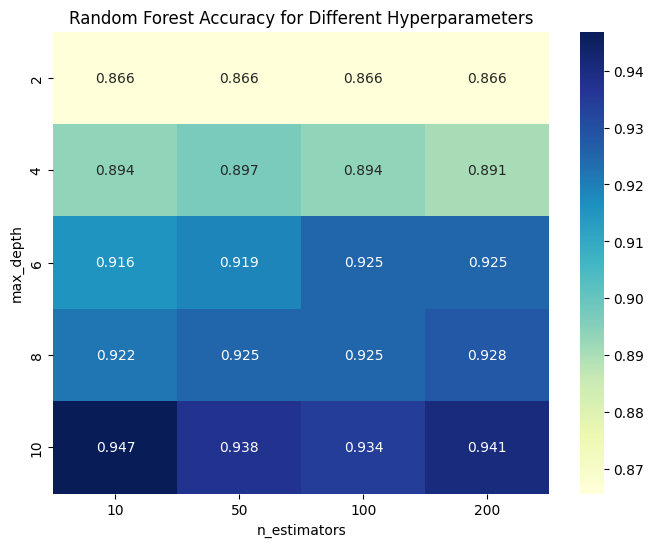

In [32]:
# Visualize results as heatmap
pivot_table = results_df.pivot(index='max_depth', columns='n_estimators', values='accuracy')

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title('Random Forest Accuracy for Different Hyperparameters')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.show()

### Reflective Question:
1. Which hyperparameter seemed to have a bigger impact on accuracy? Why might that be?

Answer: The `max_depth` hyperparameter had the biggest impact on accuracy. As the maximum depth increased, the model was able to learn more complex patterns in the data, which improved its performance. Increasing the number of trees (`n_estimators`) only produced small improvements because the forest already had enough trees to make stable predictions.

2. How would you decide which hyperparameters to tune next based on these results?

Answer: Based on these results, I would continue tuning `max_depth` because it had the greatest effect on accuracy. I would also experiment with nearby values or try additional hyperparameters such as `min_samples_split` or `max_features` to see if they could further improve the model while avoiding overfitting.

---

### 8. Grid Search (complete implementation)

Grid Search automates the manual hyperparameter tuning by exhaustively searching over a parameter grid.

In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [4, 6, 8],
    'n_estimators': [50, 100, 150],
    'max_features': ['auto', 'sqrt']
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best parameters found: {'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 50}
Best cross-validation accuracy: 0.8913


In [34]:
# Evaluate best model on test set
best_rf = grid_search.best_estimator_
test_preds = best_rf.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, test_preds))
print("Classification Report:")
print(classification_report(y_test, test_preds))

Test Accuracy: 0.925
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       277
           1       0.88      0.51      0.65        43

    accuracy                           0.93       320
   macro avg       0.90      0.75      0.80       320
weighted avg       0.92      0.93      0.92       320



### Conceptual Question:
1. What are some advantages and disadvantages of Grid Search?

Answer: Grid Search automatically tests every combination of the selected hyperparameters, making it more thorough than manually trying different values. This increases the chances of finding the best combination within the search space. However, Grid Search can be very time-consuming and computationally expensive, especially when there are many hyperparameters or possible values to test.

2. How does it compare to manual tuning?

Answer: Grid Search is more systematic than manual tuning because it evaluates every combination of the specified hyperparameter values instead of relying on trial and error. Manual tuning can be faster when testing only a few values, but it may miss better combinations. Grid Search requires more computation but provides a more reliable way to find well-performing hyperparameters.

---

## Part 2 - Student Coding Exercises

### 9. Random Search (student implements with tips)

Unlike Grid Search, Random Search samples hyperparameter combinations randomly.

**Exercise:** Implement RandomizedSearchCV on the Random Forest model to find good hyperparameters.

Hints:
- Use `RandomizedSearchCV` from `sklearn.model_selection`
- Define parameter distributions for `max_depth`, `n_estimators`, and `max_features`
- Use 20 iterations (`n_iter=20`)
- Use 5-fold cross-validation
- Evaluate and print best params and accuracy

In [35]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# YOUR CODE BELOW

# Define parameter distributions
param_dist = {
    'max_depth': randint(2, 15),
    'n_estimators': randint(10, 200),
    'max_features': ['auto', 'sqrt', 'log2', None]
}

# Initialize model
rf = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Fit to training data
random_search.fit(X_train, y_train)

# Print best parameters and accuracy
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best cross-validation accuracy: {random_search.best_score_:.4f}")

# Evaluate on test set
best_rf_random = random_search.best_estimator_
test_preds_random = best_rf_random.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, test_preds_random):.4f}")

Best parameters found: {'max_depth': 12, 'max_features': None, 'n_estimators': 198}
Best cross-validation accuracy: 0.8945
Test Accuracy: 0.9344


### Reflective Question:

1. How did the results from Random Search compare to Grid Search?

Answer: The Random Search performed slightly better than Grid Search. Grid Search achieved a test accuracy of 92.5%, while Random Search achieved about 93.4%. Random Search also found a different combination of hyperparameters because it searched a wider range of possible values.

2. Why might Random Search be more efficient than Grid Search in some cases?

Answer: Random Search can be more efficient because it tests only a fixed number of randomly selected hyperparameter combinations instead of evaluating every possible combination. This allows it to explore a larger search space in less time, especially when many hyperparameters and values are available.

---

### 10. Comparing Methods (student analysis)

**Exercise:**
- Compare the performances of manual tuning, grid search, and random search.
- Create a summary DataFrame with method, best hyperparameters, and test accuracy.
- Discuss advantages and disadvantages of each approach.

In [36]:
# YOUR CODE BELOW

summary = pd.DataFrame({
    'Method': ['Manual Tuning', 'Grid Search', 'Random Search'],
    'Best Hyperparameters': [
        results_df.loc[results_df['accuracy'].idxmax(), ['max_depth', 'n_estimators']].to_dict(),
        grid_search.best_params_,
        random_search.best_params_
    ],
    'Test Accuracy': [
        results_df['accuracy'].max(),
        accuracy_score(y_test, best_rf.predict(X_test)),
        accuracy_score(y_test, best_rf_random.predict(X_test))
    ]
})

summary

,Method,Best Hyperparameters,Test Accuracy
0,Manual Tuning,"{'max_depth': 10.0, 'n_estimators': 10.0}",0.946875
1,Grid Search,"{'max_depth': 8, 'max_features': 'sqrt', 'n_es...",0.925000
2,Random Search,"{'max_depth': 12, 'max_features': None, 'n_est...",0.934375


### Reflective Question:
1. Which method would you choose for a real-world project and why?

Answer: I would choose Random Search for a real-world project because it can explore a larger range of hyperparameter values while using less time and computational resources than Grid Search. It often finds very good hyperparameters without having to evaluate every possible combination, making it a practical choice for larger machine learning problems.

2. What factors (time, computational resources, dataset size) might influence your choice?

Answer: The choice depends on the amount of time available, the computing resources, and the size of the dataset. For smaller datasets or when the search space is limited, Grid Search can be a good option because it tests every combination. For larger datasets or more complex models, Random Search is usually more efficient because it requires fewer model evaluations while still finding strong hyperparameter combinations.

---

### 11. AutoML with AutoGluon (guided then student exercise)

AutoML tools like AutoGluon automate the entire model building and tuning process.

Let's first install and import AutoGluon, then run an AutoML experiment.

In [38]:
# Uncomment the next line to install AutoGluon if it's not installed
!pip install autogluon.tabular -q

from autogluon.tabular import TabularPredictor

# Prepare DataFrame for AutoGluon
train_data = X_train.copy()
train_data['good_quality'] = y_train.values

test_data = X_test.copy()
test_data['good_quality'] = y_test.values

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 6.7 MB/s eta 0:00:00


**Guided Exercise:**
Train an AutoGluon predictor and evaluate performance.

Use `time_limit=60` seconds for quick demonstration.

Observe the leaderboard and test accuracy.

In [39]:
# YOUR CODE BELOW

predictor = TabularPredictor(label='good_quality', eval_metric='accuracy').fit(
    train_data=train_data,
    time_limit=60,
    verbosity=2
)

# Show leaderboard
leaderboard = predictor.leaderboard(silent=True)
leaderboard

No path specified. Models will be saved in: "AutogluonModels/ag-20260714_203454"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.86 GB / 12.67 GB (85.7%)
Disk Space Avail:   87.67 GB / 107.72 GB (81.4%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.a

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,XGBoost,0.917969,accuracy,0.005641,0.754751,0.005641,0.754751,1,True,8
1,WeightedEnsemble_L2,0.917969,accuracy,0.006640,0.852531,0.000999,0.097780,2,True,11
2,ExtraTreesGini,0.914062,accuracy,0.109102,1.485862,0.109102,1.485862,1,True,5
3,LightGBM,0.910156,accuracy,0.004777,1.316519,0.004777,1.316519,1,True,2
4,LightGBMXT,0.910156,accuracy,0.014912,9.418479,0.014912,9.418479,1,True,1
5,LightGBMLarge,0.902344,accuracy,0.001286,2.539931,0.001286,2.539931,1,True,10
6,NeuralNetFastAI,0.902344,accuracy,0.022588,3.909963,0.022588,3.909963,1,True,7
7,RandomForestGini,0.902344,accuracy,0.101472,1.888521,0.101472,1.888521,1,True,3
8,RandomForestEntr,0.902344,accuracy,0.105099,1.872721,0.105099,1.872721,1,True,4
9,ExtraTreesEntr,0.898438,accuracy,0.096727,1.313839,0.096727,1.313839,1,True,6


In [40]:
# Evaluate on test data
y_pred_automl = predictor.predict(test_data.drop(columns=['good_quality']))
acc_automl = accuracy_score(test_data['good_quality'], y_pred_automl)
print(f"AutoGluon Test Accuracy: {acc_automl:.4f}")

AutoGluon Test Accuracy: 0.9406


### Student Exercise:
- Try increasing the `time_limit` to 180 seconds and retrain.
- Observe how the leaderboard and accuracy change.
- Experiment with excluding some model types by setting `excluded_model_types` in `fit()`.
- Report your findings.

---

### 12. Final Comparison & Reflection

Summarize your findings across all tuning methods:
- Manual tuning
- Grid Search
- Random Search
- AutoML (AutoGluon)

Consider accuracy, time, complexity, and ease of use.

### Reflective Questions:

1. What tradeoffs did you observe between manual and automated tuning?

Answer: Manual tuning gives you more control and helps you understand how each hyperparameter affects the model, but it can take a lot of time and may not find the best combination. Automated tuning with AutoML is much faster and can evaluate many models and hyperparameter combinations automatically, but it requires more computational resources and gives the user less direct control over the process.

2. When might AutoML be preferred? When might manual tuning still be useful?

Answer: AutoML is preferred when working with large datasets, multiple models, or when a strong baseline model is needed quickly. Manual tuning is still useful when learning machine learning concepts, understanding how hyperparameters affect performance, or when fine-tuning a specific model for a particular application.

3. How does understanding hyperparameters help even when using AutoML?

Answer: Understanding hyperparameters is important because it helps you interpret the results produced by AutoML and make informed decisions about the models it selects. It also allows you to adjust search ranges, troubleshoot model performance, and understand why one model performs better than another.

In [41]:
# Use this cell to write your summary and answers
from IPython.display import display

summary

,Method,Best Hyperparameters,Test Accuracy
0,Manual Tuning,"{'max_depth': 10.0, 'n_estimators': 10.0}",0.946875
1,Grid Search,"{'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 50}",0.925000
2,Random Search,"{'max_depth': 12, 'max_features': None, 'n_estimators': 198}",0.934375


---

### Congratulations! You have completed Module 11 on Hyperparameter Tuning & AutoML.

Please submit your notebook and reflect on how hyperparameter tuning can be incorporated into your future machine learning projects.